# Análise de Sentimentos com NLP
## Classificação de Revisões do IMDB

**Dataset**: IMDB Movie Reviews - 50.000 revisões balanceadas (25.000 positivas, 25.000 negativas)

## Metodologia

### 1. Pré-processamento
- **Bag of Words (BoW)**: Representação baseada em contagem de palavras
- **TF-IDF**: Representação que pondera a importância das palavras

### 2. Modelo
- **Regressão Logística**: Classificador linear eficiente para texto
- **Configuração**: max_iter=1000 para garantir convergência

### 3. Avaliação
- Acurácia
- Relatório de classificação (precision, recall, F1-score)

In [61]:
import os
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

import matplotlib.pyplot as plt

In [62]:
def carregar_dados(base_path):
    textos = []
    labels = []

    for label, sentimento in enumerate(["neg", "pos"]):
        caminho = os.path.join(base_path, sentimento)

        for arquivo in os.listdir(caminho):
            if arquivo.endswith(".txt"):
                with open(os.path.join(caminho, arquivo), encoding="utf-8") as f:
                    textos.append(f.read())
                    labels.append(label)

    return textos, labels


In [63]:
X_train, y_train = carregar_dados("../data/raw/imdb/train")
X_test, y_test = carregar_dados("../data/raw/imdb/test")

print("Treino:", len(X_train))
print("Teste:", len(X_test))

Treino: 25000
Teste: 25000


## Bag of Words

In [64]:
vectorizer_bow = CountVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

X_train_bow = vectorizer_bow.fit_transform(X_train)
X_test_bow = vectorizer_bow.transform(X_test)

print("Dimensão BoW:", X_train_bow.shape)

Dimensão BoW: (25000, 156816)


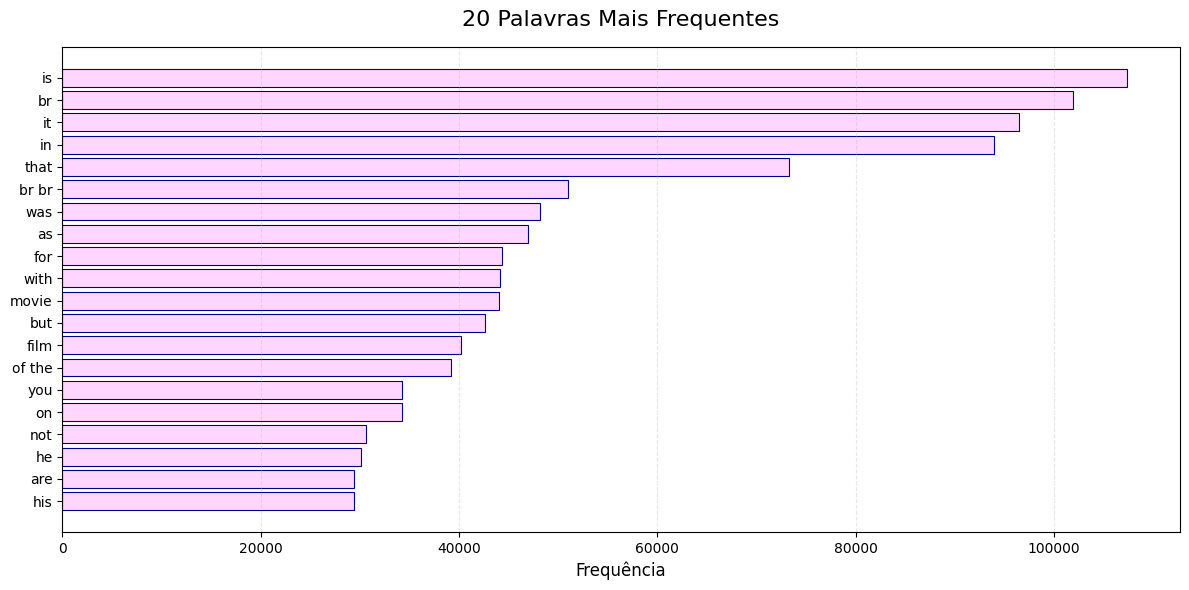

In [65]:
# Soma as ocorrências de cada palavra
word_counts = np.array(X_train_bow.sum(axis=0)).flatten()
words = vectorizer_bow.get_feature_names_out()

# Top N palavras mais frequentes
top_n = 20
top_indices = np.argsort(word_counts)[-top_n:]
top_words = [words[i] for i in top_indices]
top_counts = word_counts[top_indices]

plt.figure(figsize=(12, 6))
bars = plt.barh(range(top_n), top_counts, color='#ffd6ff', edgecolor='darkblue', linewidth=0.8)
plt.yticks(range(top_n), top_words)
plt.xlabel('Frequência', fontsize=12)
plt.title(f'{top_n} Palavras Mais Frequentes', fontsize=16, pad=15)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

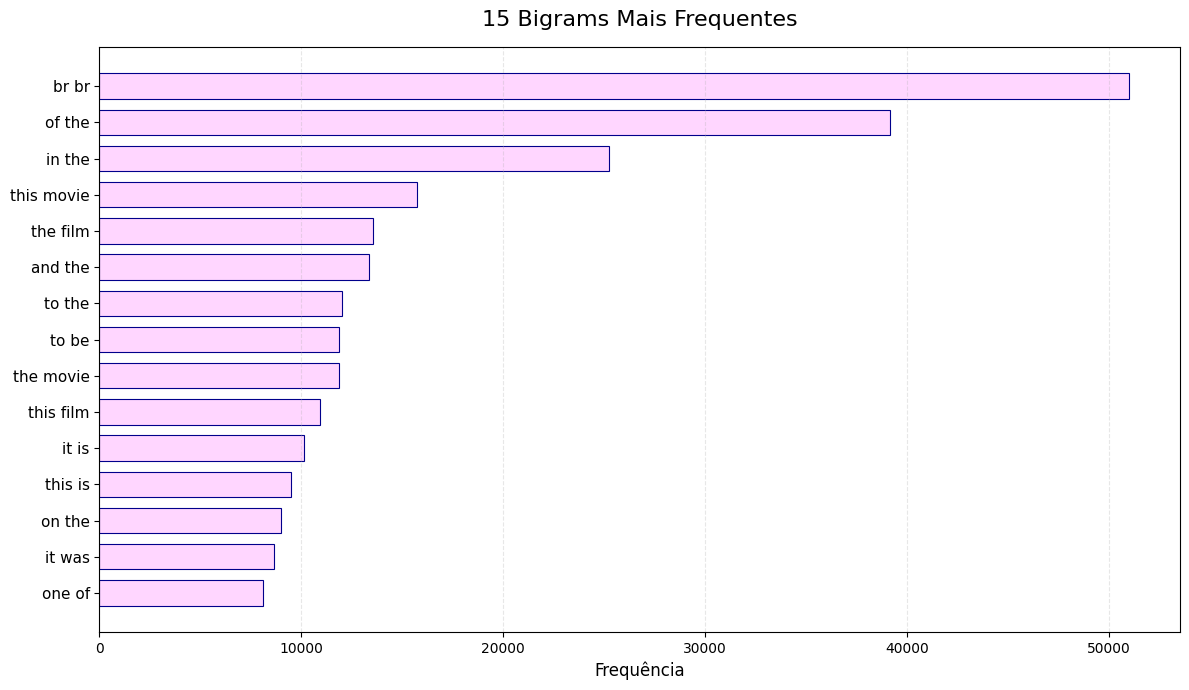

Total de bigrams únicos: 129549
Bigrams com frequência >= 5: 129549


In [76]:
# Extrai apenas bigrams
vectorizer_bigrams = CountVectorizer(ngram_range=(2, 2), min_df=5)
X_bigrams = vectorizer_bigrams.fit_transform(X_train)
bigram_counts = np.array(X_bigrams.sum(axis=0)).flatten()
bigrams = vectorizer_bigrams.get_feature_names_out()

# Top bigrams - CORREÇÃO: usar len(top_bigrams) em vez de top_n
top_n_bigrams = 15  # Defina o número de bigrams que quer mostrar
top_bigrams_idx = np.argsort(bigram_counts)[-top_n_bigrams:]
top_bigrams = [bigrams[i] for i in top_bigrams_idx]
top_bigram_counts = bigram_counts[top_bigrams_idx]

plt.figure(figsize=(12, 7))

# CORREÇÃO: usar len(top_bigrams) no range e top_bigram_counts nos valores
bars = plt.barh(range(len(top_bigrams)), top_bigram_counts, 
                color='#ffd6ff', 
                edgecolor='darkblue', 
                linewidth=0.8,
                height=0.7)

plt.yticks(range(len(top_bigrams)), top_bigrams, fontsize=11)
plt.xlabel('Frequência', fontsize=12)
plt.title(f'{len(top_bigrams)} Bigrams Mais Frequentes', fontsize=16, pad=15)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Estatísticas
print(f"Total de bigrams únicos: {len(bigrams)}")
print(f"Bigrams com frequência >= 5: {np.sum(bigram_counts >= 5)}")

Número de palavras no vocabulário: 156816
Shape do word_counts: (156816,)


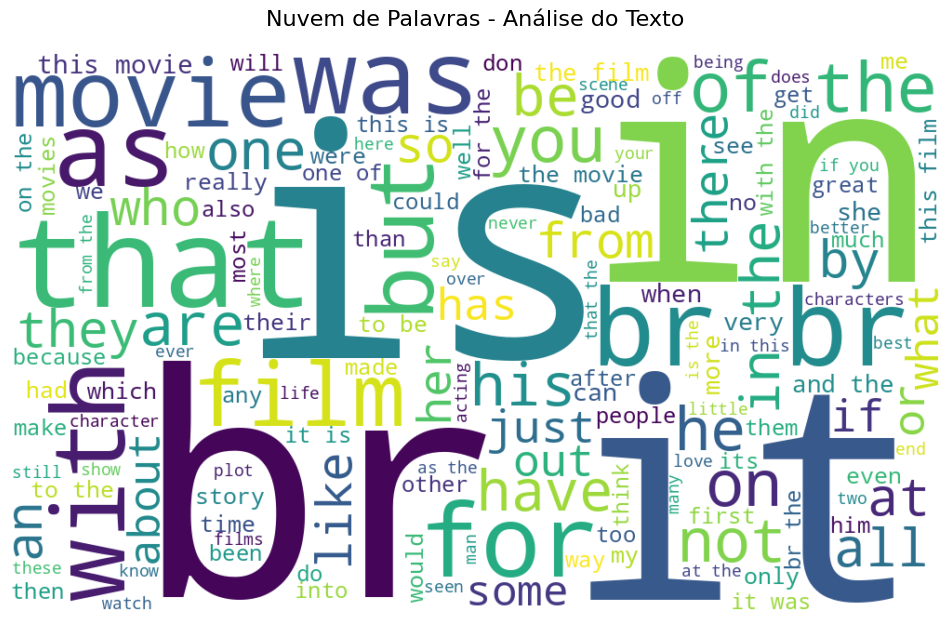

In [67]:
from wordcloud import WordCloud

# 1. PRIMEIRO: Extrair as palavras e frequências da sua matriz BoW
words = vectorizer_bow.get_feature_names_out()  # Nomes das features (palavras)
word_counts = np.array(X_train_bow.sum(axis=0)).flatten()  # Soma total de cada palavra

# 2. Verificar se as variáveis foram criadas
print(f"Número de palavras no vocabulário: {len(words)}")
print(f"Shape do word_counts: {word_counts.shape}")

# 3. AGORA criar o dicionário para a wordcloud
freq_dict = dict(zip(words, word_counts))

# 4. Criar a wordcloud
plt.figure(figsize=(12, 8))
wordcloud = WordCloud(
    width=1000, 
    height=600,
    background_color='white',
    max_words=150,
    colormap='viridis',
    contour_width=1,
    contour_color='steelblue'
).generate_from_frequencies(freq_dict)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras - Análise do Texto', fontsize=16, pad=20)
plt.show()

In [68]:
modelo_bow = LogisticRegression(max_iter=1000)
modelo_bow.fit(X_train_bow, y_train)

y_pred_bow = modelo_bow.predict(X_test_bow)

print("Acurácia BoW:", accuracy_score(y_test, y_pred_bow))
print(classification_report(y_test, y_pred_bow))



Acurácia BoW: 0.8936
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     12500
           1       0.89      0.89      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



In [69]:
accuracy = accuracy_score(y_test, y_pred_bow)
report_dict = classification_report(y_test, y_pred_bow, target_names=['Negativo', 'Positivo'], output_dict=True)

report_df = pd.DataFrame(report_dict).transpose()

print("RESULTADOS BOW - CLASSIFICAÇÃO DE SENTIMENTOS")
print("═" * 55)
print(f"Acurácia Geral: {accuracy:.4f}")
print("═" * 55)
print("\nMétricas:")
print(report_df.round(4).to_string())
print("═" * 55)

# Formatação estilizada alternativa
print("\n" + "Resumo de Desempenho".center(60))
print("─" * 60)
for label in ['Negativo', 'Positivo']:
    prec = report_dict[label]['precision']
    rec = report_dict[label]['recall']
    f1 = report_dict[label]['f1-score']
    print(f"  {label:10} | P: {prec:.3f} | R: {rec:.3f} | F1: {f1:.3f}")
print("─" * 60)

RESULTADOS BOW - CLASSIFICAÇÃO DE SENTIMENTOS
═══════════════════════════════════════════════════════
Acurácia Geral: 0.8936
═══════════════════════════════════════════════════════

Métricas:
              precision  recall  f1-score     support
Negativo         0.8941  0.8930    0.8935  12500.0000
Positivo         0.8931  0.8942    0.8937  12500.0000
accuracy         0.8936  0.8936    0.8936      0.8936
macro avg        0.8936  0.8936    0.8936  25000.0000
weighted avg     0.8936  0.8936    0.8936  25000.0000
═══════════════════════════════════════════════════════

                    Resumo de Desempenho                    
────────────────────────────────────────────────────────────
  Negativo   | P: 0.894 | R: 0.893 | F1: 0.894
  Positivo   | P: 0.893 | R: 0.894 | F1: 0.894
────────────────────────────────────────────────────────────


## TF-IDF

In [70]:
vectorizer_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

print("Dimensão TF-IDF:", X_train_tfidf.shape)

Dimensão TF-IDF: (25000, 156816)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))



# B. Top palavras com maior TF-IDF médio
# Calcula TF-IDF médio por palavra
tfidf_means = np.array(X_train_tfidf.mean(axis=0)).flatten()
tfidf_words = vectorizer_tfidf.get_feature_names_out()

top_n_tfidf = 15
top_tfidf_idx = np.argsort(tfidf_means)[-top_n_tfidf:]
top_tfidf_words = [tfidf_words[i] for i in top_tfidf_idx]
top_tfidf_vals = tfidf_means[top_tfidf_idx]

axes[1].barh(range(len(top_tfidf_words)), top_tfidf_vals, 
             color='#4ECDC4', edgecolor='#1A535C', linewidth=1)
axes[1].set_yticks(range(len(top_tfidf_words)))
axes[1].set_yticklabels(top_tfidf_words, fontsize=10)
axes[1].set_xlabel('TF-IDF Médio', fontsize=11, fontweight='bold')
axes[1].set_title(f'Top {top_n_tfidf} Palavras com Maior TF-IDF', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [71]:
modelo_tfidf = LogisticRegression(max_iter=1000)
modelo_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = modelo_tfidf.predict(X_test_tfidf)

print("Acurácia TF-IDF:", accuracy_score(y_test, y_pred_tfidf))
print(classification_report(y_test, y_pred_tfidf))

Acurácia TF-IDF: 0.90008
              precision    recall  f1-score   support

           0       0.90      0.89      0.90     12500
           1       0.90      0.91      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



In [72]:
accuracy = accuracy_score(y_test, y_pred_tfidf)
report_dict = classification_report(y_test, y_pred_tfidf, target_names=['Negativo', 'Positivo'], output_dict=True)

report_df = pd.DataFrame(report_dict).transpose()

print("RESULTADOS TF-IDF - CLASSIFICAÇÃO DE SENTIMENTOS")
print("═" * 55)
print(f"Acurácia Geral: {accuracy:.4f}")
print("═" * 55)
print("\nMétricas:")
print(report_df.round(4).to_string())
print("═" * 55)

print("\n" + "Resumo de Desempenho".center(60))
print("─" * 60)
for label in ['Negativo', 'Positivo']:
    prec = report_dict[label]['precision']
    rec = report_dict[label]['recall']
    f1 = report_dict[label]['f1-score']
    print(f"  {label:10} | P: {prec:.3f} | R: {rec:.3f} | F1: {f1:.3f}")
print("─" * 60)

RESULTADOS TF-IDF - CLASSIFICAÇÃO DE SENTIMENTOS
═══════════════════════════════════════════════════════
Acurácia Geral: 0.9001
═══════════════════════════════════════════════════════

Métricas:
              precision  recall  f1-score     support
Negativo         0.9042  0.8950    0.8996  12500.0000
Positivo         0.8960  0.9052    0.9006  12500.0000
accuracy         0.9001  0.9001    0.9001      0.9001
macro avg        0.9001  0.9001    0.9001  25000.0000
weighted avg     0.9001  0.9001    0.9001  25000.0000
═══════════════════════════════════════════════════════

                    Resumo de Desempenho                    
────────────────────────────────────────────────────────────
  Negativo   | P: 0.904 | R: 0.895 | F1: 0.900
  Positivo   | P: 0.896 | R: 0.905 | F1: 0.901
────────────────────────────────────────────────────────────


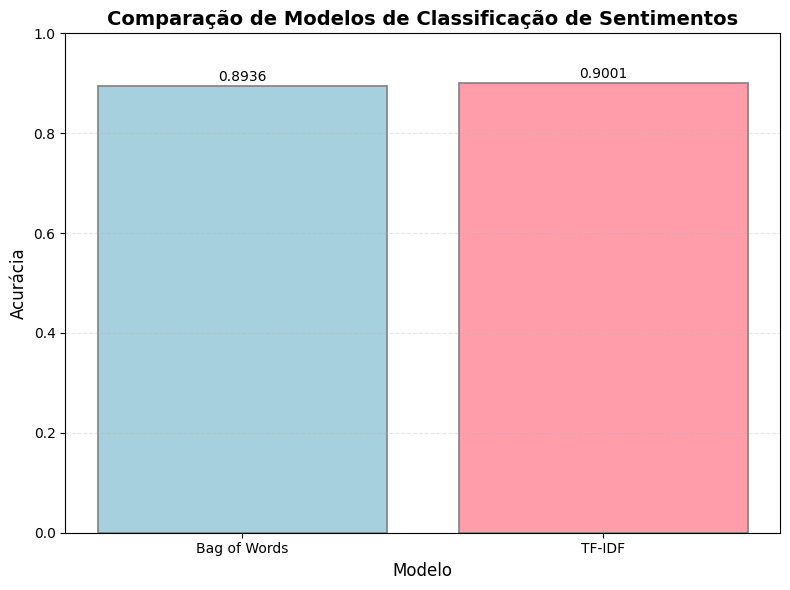

In [73]:
resultados = pd.DataFrame({
    "Modelo": ["Bag of Words", "TF-IDF"],
    "Acurácia": [
        accuracy_score(y_test, y_pred_bow),
        accuracy_score(y_test, y_pred_tfidf)
    ]
})

# Cores pastéis - azul e rosa
cores_pasteis = ['#A6D0DD', '#FF9EAA']  # Azul pastel e rosa pastel

plt.figure(figsize=(8, 6))
plt.bar(resultados["Modelo"], resultados["Acurácia"], color=cores_pasteis, edgecolor='gray', linewidth=1.2)
plt.ylim(0, 1)
plt.title("Comparação de Modelos de Classificação de Sentimentos", fontsize=14, fontweight='bold')
plt.ylabel("Acurácia", fontsize=12)
plt.xlabel("Modelo", fontsize=12)

# Adicionar os valores das barras
for i, v in enumerate(resultados["Acurácia"]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

# Melhorar a aparência
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

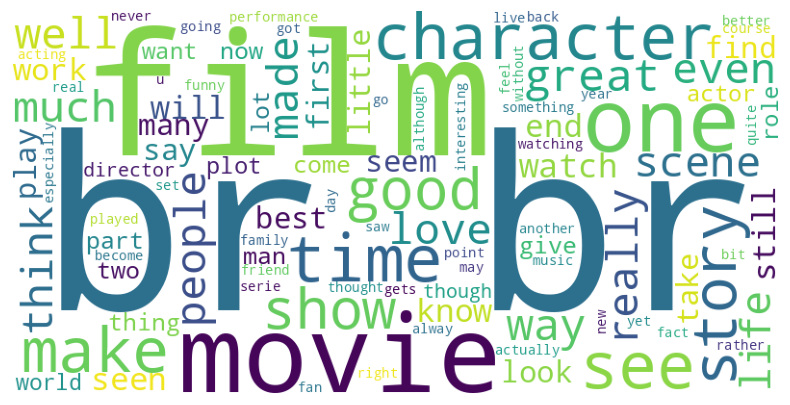

In [74]:
from wordcloud import WordCloud

texto_pos = " ".join(
    [X_train[i] for i in range(len(y_train)) if y_train[i] == 1]
)

wc = WordCloud(
    background_color="white",
    max_words=100,
    width=800,
    height=400
).generate(texto_pos)

plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis("off")
plt.show()

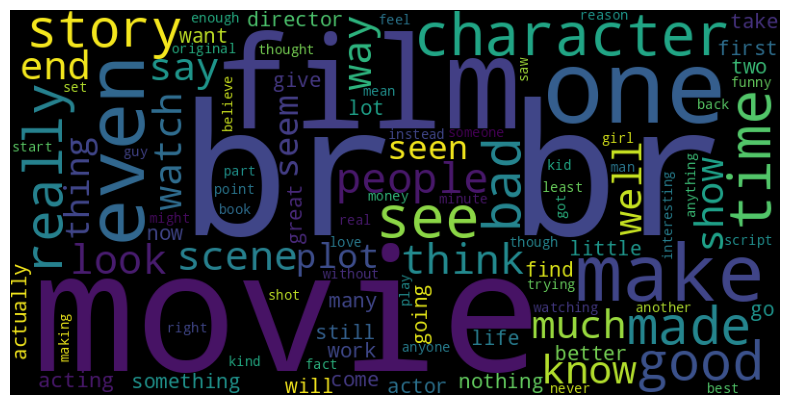

In [75]:
texto_neg = " ".join(
    [X_train[i] for i in range(len(y_train)) if y_train[i] == 0]
)

wc = WordCloud(
    background_color="black",
    max_words=100,
    width=800,
    height=400
).generate(texto_neg)

plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis("off")
plt.show()